## Classification - Binary (label)

Workflow:
1. Load datasets and target
2. Define models via Pipeline (VarianceThreshold + SelectKBest + Classifier)
3. Run GridSearchCV to optimize Pipeline hyperparameters
4. Display the collected results
5. Show confusion matrix and classification report for the best model on test Set
6. Save best model

In [1]:
# 1. Load reduced datasets and target

import pandas as pd

X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")

y_train = pd.read_parquet("../data/processed/y_label_train.parquet")['label']
y_test = pd.read_parquet("../data/processed/y_label_test.parquet")['label']

In [2]:
# 2. Define models via Pipeline (VarianceThreshold + SelectKBest + Classifier)

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

random_state = 42

models = {
    'dt': {
        'name': 'Decision Tree',
        'estimator': Pipeline([
            ('variance', VarianceThreshold(threshold=0)),
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', DecisionTreeClassifier(random_state=random_state))
        ]),
        'param': [{
            'selector__k': [30, 40, 50],
            'classifier__max_depth': [5, 10, 15, 20],
            'classifier__criterion': ['entropy', 'gini'],
            'classifier__class_weight': [None, 'balanced']
        }]
    },
    'rf': {
        'name': 'Random Forest',
        'estimator': Pipeline([
            ('variance', VarianceThreshold(threshold=0)),
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', RandomForestClassifier(random_state=random_state))
        ]),
        'param': [{
            'selector__k': [30, 40, 50],
            'classifier__n_estimators': [20, 30, 40, 50],
            'classifier__max_depth': [5, 10, 15, None],
            'classifier__class_weight': [None, 'balanced']
        }]
    }
}

In [3]:
# 3. Run GridSearchCV to optimize Pipeline hyperparameters

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

scoring = {
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'accuracy': 'accuracy'
}
cv = StratifiedKFold(n_splits=3, random_state=random_state, shuffle=True)

clfs = {}
results = pd.DataFrame(columns=['model_lbl', 'best_params', 'accuracy', 'precision', 'recall', 'f1', 'f1_std'])

for model_lbl, model_info in models.items():
    print(f"Tuning {model_info['name']}...")

    clf = GridSearchCV(
        model_info['estimator'],
        model_info['param'],
        cv=cv,
        scoring=scoring,
        refit='f1',
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    
    idx = clf.best_index_
    cv_res = clf.cv_results_
    clfs[model_lbl] = clf

    results.loc[len(results)] = [
        model_lbl,
        clf.best_params_,
        cv_res['mean_test_accuracy'][idx],
        cv_res['mean_test_precision'][idx],
        cv_res['mean_test_recall'][idx],
        cv_res['mean_test_f1'][idx],
        cv_res['std_test_f1'][idx]
    ]

print("\nDone.")

Tuning Decision Tree...
Tuning Random Forest...

Done.


In [4]:
# 4. Display the collected results

results = results.sort_values(by='f1', ascending=False).reset_index(drop=True)

display(
    results.style.format(precision=3)
           .set_caption('Binary classification results (label)')
)

,model_lbl,best_params,accuracy,precision,recall,f1,f1_std
0,rf,"{'classifier__class_weight': None, 'classifier__max_depth': 15, 'classifier__n_estimators': 30, 'selector__k': 50}",0.918,0.882,0.963,0.921,0.003
1,dt,"{'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 15, 'selector__k': 40}",0.914,0.887,0.946,0.916,0.002


Best combination: Random Forest
Best params: {'classifier__class_weight': None, 'classifier__max_depth': 15, 'classifier__n_estimators': 30, 'selector__k': 50}

              precision    recall  f1-score   support

           0       0.96      0.88      0.92     16135
           1       0.88      0.96      0.92     15817

    accuracy                           0.92     31952
   macro avg       0.92      0.92      0.92     31952
weighted avg       0.92      0.92      0.92     31952



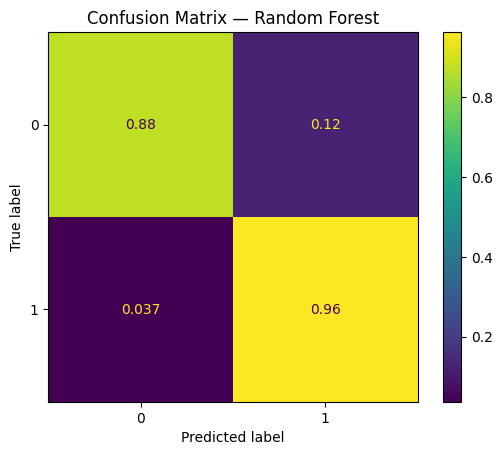

In [5]:
# 5. Show confusion matrix and classification report for the best model on test set

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_key = results.loc[0, 'model_lbl']
best_label = models[best_key]['name']
best_clf = clfs[best_key]

y_pred_best = best_clf.predict(X_test)

print(f"Best combination: {best_label}")
print(f"Best params: {results.loc[0, 'best_params']}")
print()
print(classification_report(y_test, y_pred_best, zero_division=0))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, normalize='true')
disp.ax_.set_title(f"Confusion Matrix — {best_label}")
plt.show()

In [6]:
# 6. Save best model

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_clf, "../models/best_model_bin.pkl")
print("Best binary model saved to ../models/best_model_bin.pkl")

Best binary model saved to ../models/best_model_bin.pkl
